In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

In [4]:
# Binary Classification using Linear and Logistic Regression

# X_test, y_pred : Simple model score
# X_test, y_test : X_test value internally test/train then score
# y_test, y_pred : classification
# Q Diff bw score and accuracy


In [5]:
x = np.random.random(30)
x

array([0.52118461, 0.93091821, 0.81503978, 0.97347552, 0.59340601,
       0.74999899, 0.93026   , 0.69946582, 0.96754434, 0.37050392,
       0.23505584, 0.30029923, 0.12797743, 0.03995136, 0.7604049 ,
       0.30415969, 0.07048453, 0.16653651, 0.48849033, 0.34778418,
       0.32857519, 0.02662879, 0.27568719, 0.21978731, 0.27842977,
       0.76104974, 0.0422824 , 0.94488272, 0.43867518, 0.02838375])

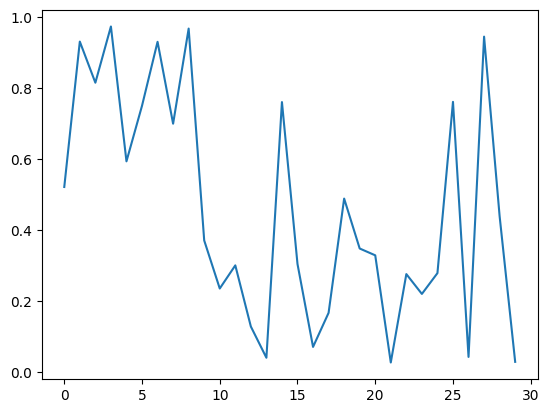

In [6]:
plt.plot(x)
plt.show()

In [7]:
# create sigmoid function

def sigmoid_fun(x):
    return (1 / (1 + 2.71 ** (-x)))

sigmoid_x = sigmoid_fun(x)

sigmoid_x

array([0.62705289, 0.71668512, 0.69265322, 0.72522016, 0.6437311 ,
       0.67867962, 0.71655186, 0.66759586, 0.72404026, 0.59130756,
       0.55831802, 0.57429166, 0.53185353, 0.50995605, 0.68093774,
       0.57523231, 0.51756014, 0.541412  , 0.6193994 , 0.58582268,
       0.58116863, 0.50663649, 0.56828219, 0.55456104, 0.56895287,
       0.6810774 , 0.51053679, 0.71950338, 0.60762422, 0.50707381])

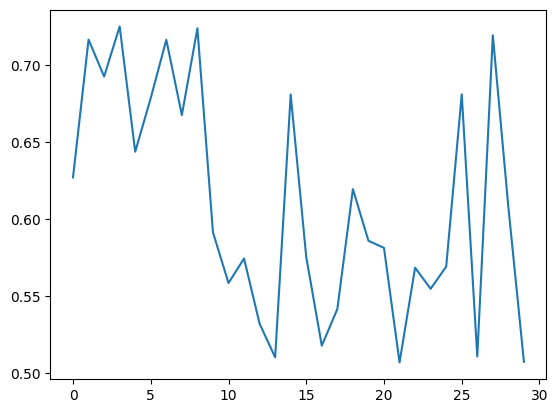

In [8]:
plt.plot(sigmoid_x)

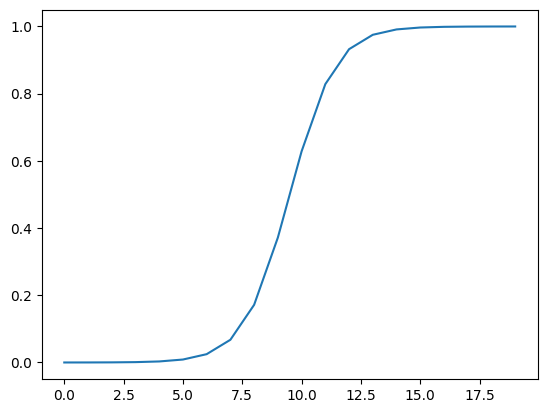

In [9]:
new_x = np.linspace(-10, 10, 20)
sigmoid_x_new = sigmoid_fun(new_x)
plt.plot(sigmoid_x_new)

In [10]:
df = pd.read_csv("myinsurance.csv")
df.head()

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,Male,25000,0,Single,0,0,1,No
1,2,25,Female,30000,0,Single,0,0,1,No
2,3,28,Male,35000,1,Single,0,0,1,No
3,4,30,Female,40000,1,Single,0,1,2,Yes
4,5,32,Male,45000,1,Single,0,1,2,Yes


In [11]:
df.shape

(100, 10)

In [12]:
df = df.drop(columns="Customer_ID")

In [13]:
df.shape

(100, 9)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 100 non-null    int64 
 1   Gender              100 non-null    object
 2   Annual_Income       100 non-null    int64 
 3   Employment_Status   100 non-null    int64 
 4   Marital_Status      100 non-null    object
 5   Married             100 non-null    int64 
 6   Previous_Insurance  100 non-null    int64 
 7   Family_Size         100 non-null    int64 
 8   Buy_Insurance       100 non-null    object
dtypes: int64(6), object(3)
memory usage: 7.2+ KB


In [15]:
df.corr(numeric_only=True)

,Age,Annual_Income,Employment_Status,Married,Previous_Insurance,Family_Size
Age,1.000000,0.998332,0.650960,0.834590,0.960055,0.956927
Annual_Income,0.998332,1.000000,0.650526,0.839337,0.961360,0.957596
Employment_Status,0.650960,0.650526,1.000000,0.557578,0.610820,0.689424
Married,0.834590,0.839337,0.557578,1.000000,0.820608,0.848247
Previous_Insurance,0.960055,0.961360,0.610820,0.820608,1.000000,0.933681
Family_Size,0.956927,0.957596,0.689424,0.848247,0.933681,1.000000


In [16]:
# Convert object columns to string dtype
df[df.select_dtypes(include="object").columns] = \
    df.select_dtypes(include="object").astype("string")

# Now select string columns
text_data = list(df.select_dtypes(include="string").columns)

text_data

['Gender', 'Marital_Status', 'Buy_Insurance']

In [17]:
for i in text_data:
    print(f"Analysis Data {i}")
    display(df[i].value_counts())

Analysis Data Gender


Gender
Male      50
Female    50
Name: count, dtype: Int64

Analysis Data Marital_Status


Marital_Status
Married    51
Single     49
Name: count, dtype: Int64

Analysis Data Buy_Insurance


Buy_Insurance
Yes    69
No     31
Name: count, dtype: Int64

In [18]:
df["Gender"] = df["Gender"].replace({'Male' : 0, 'Female' : 1})
df

C:\Users\Harnoor kaur\AppData\Local\Temp\ipykernel_32208\4096947460.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace({'Male' : 0, 'Female' : 1})


,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,22,0,25000,0,Single,0,0,1,No
1,25,1,30000,0,Single,0,0,1,No
2,28,0,35000,1,Single,0,0,1,No
3,30,1,40000,1,Single,0,1,2,Yes
4,32,0,45000,1,Single,0,1,2,Yes
...,...,...,...,...,...,...,...,...,...
95,46,1,70000,1,Married,1,2,4,Yes
96,51,0,83000,1,Married,1,3,4,Yes
97,56,1,94000,1,Married,1,3,4,Yes
98,24,0,31000,0,Single,0,0,1,No


In [19]:
df["Marital_Status"] = df["Marital_Status"].replace({'Single' : 0, 'Married' : 1})

C:\Users\Harnoor kaur\AppData\Local\Temp\ipykernel_32208\3389318271.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Marital_Status"] = df["Marital_Status"].replace({'Single' : 0, 'Married' : 1})


In [20]:
df["Buy_Insurance"] = df["Buy_Insurance"].replace({'No' : 0, 'Yes' : 1})

C:\Users\Harnoor kaur\AppData\Local\Temp\ipykernel_32208\3133920246.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Buy_Insurance"] = df["Buy_Insurance"].replace({'No' : 0, 'Yes' : 1})


In [21]:
df.corr().round(2)

,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
Age,1.00,0.02,1.00,0.65,0.83,0.83,0.96,0.96,0.73
Gender,0.02,1.00,0.02,-0.02,-0.02,-0.02,0.02,0.01,0.02
Annual_Income,1.00,0.02,1.00,0.65,0.84,0.84,0.96,0.96,0.73
Employment_Status,0.65,-0.02,0.65,1.00,0.56,0.56,0.61,0.69,0.82
Marital_Status,0.83,-0.02,0.84,0.56,1.00,1.00,0.82,0.85,0.68
Married,0.83,-0.02,0.84,0.56,1.00,1.00,0.82,0.85,0.68
Previous_Insurance,0.96,0.02,0.96,0.61,0.82,0.82,1.00,0.93,0.75
Family_Size,0.96,0.01,0.96,0.69,0.85,0.85,0.93,1.00,0.77
Buy_Insurance,0.73,0.02,0.73,0.82,0.68,0.68,0.75,0.77,1.00


In [22]:
X = df.drop(columns=  "Buy_Insurance")
y = df["Buy_Insurance"]

In [23]:
X.shape

(100, 8)

In [24]:
y.shape

(100,)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 8)
(20, 8)
(80,)
(20,)


In [27]:
model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred = model.predict(X_test)
y_pred

array([ 0.71072184,  1.12604542,  0.9805892 ,  0.9277091 ,  0.85674055,
        0.97519146,  0.79790808,  0.88099038, -0.16123934,  0.01860019,
       -0.0217355 ,  1.01000544, -0.02670258, -0.00486368,  0.01102285,
        0.77736299,  0.78936777,  1.09662918,  0.79585977,  1.01692078])

In [30]:
y_test 

83    0
53    1
70    1
45    1
44    1
39    1
22    1
80    1
10    0
0     0
18    0
30    1
73    0
33    0
90    0
4     1
76    1
77    1
12    1
31    1
Name: Buy_Insurance, dtype: int64

In [31]:
sigmoid_fun(y_pred)

array([0.67008138, 0.75447242, 0.72663116, 0.71603505, 0.70143202,
       0.72556093, 0.68900536, 0.70647026, 0.45989948, 0.50463572,
       0.49458292, 0.73241765, 0.49334512, 0.49878779, 0.50274728,
       0.68459955, 0.68717802, 0.74899942, 0.68856763, 0.73376663])

In [32]:
final_y_pred = [round(i) for i in sigmoid_fun(y_pred)]
final_y_pred


[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1]

In [33]:
score = model.score(X_test, y_test)
score

0.8295024967963704

In [34]:
model_logistic = LogisticRegression()
model_logistic

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
model_logistic.fit(X_train, y_train)
y_train.shape

C:\Users\Harnoor kaur\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


(80,)

In [36]:
print(y_train.dtype)

int64


In [37]:
y_prd = model.predict(X_test)
y_prd

array([ 0.71072184,  1.12604542,  0.9805892 ,  0.9277091 ,  0.85674055,
        0.97519146,  0.79790808,  0.88099038, -0.16123934,  0.01860019,
       -0.0217355 ,  1.01000544, -0.02670258, -0.00486368,  0.01102285,
        0.77736299,  0.78936777,  1.09662918,  0.79585977,  1.01692078])

In [38]:
sigmoid_fun(y_prd)

array([0.67008138, 0.75447242, 0.72663116, 0.71603505, 0.70143202,
       0.72556093, 0.68900536, 0.70647026, 0.45989948, 0.50463572,
       0.49458292, 0.73241765, 0.49334512, 0.49878779, 0.50274728,
       0.68459955, 0.68717802, 0.74899942, 0.68856763, 0.73376663])

In [39]:
final_y_prd = [round(i) for i in sigmoid_fun(y_prd)]
final_y_pred

[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1]

In [40]:
score = model_logistic.score(X_test, y_test)
print(score)

0.95


In [41]:
age = int(input("Enter age :"))
gender = int(input("Enter gender :"))
income = int(input("Enter income :"))
status = int(input("Enter Status :"))
marital = int(input("Enter Marital Status :"))
married = int(input("Enter Married :"))
prev_ins = int(input("Enter prev_ins :"))
f_size = int(input("Enter Family Size :"))

new_data = [[
    age, gender,
    income, status,
    marital, married,
    prev_ins, f_size
]]

prediction = model_logistic.predict(new_data)[0]

ans = "NO" if prediction == 0 else "Yes"

print(ans)

Yes


C:\Users\Harnoor kaur\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


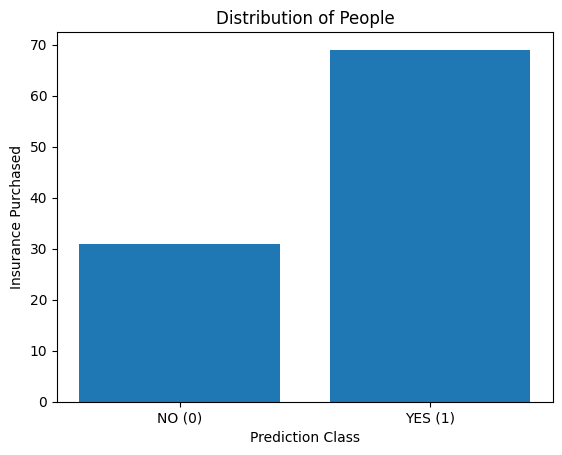

In [42]:


plt.bar(
    ["NO (0)", "YES (1)"],
    df["Buy_Insurance"].value_counts().sort_index()
)

plt.xlabel("Prediction Class")
plt.ylabel("Insurance Purchased")
plt.title("Distribution of People")

plt.show()